In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from scipy.interpolate import griddata
import sys, os

# Add project root to the system path for module import
sys.path.append(os.path.abspath('Option_Pricer'))

# Import our custom functions from the utils directory
from utils.implied_volatility import fetch_and_prepare_data, calculate_implied_volatility

In [ ]:
# Script Parameters
TICKER = 'SPY'
NUM_EXPIRIES = 12
RISK_FREE_RATE = 0.0525
STRIKE_RANGE_PCT = 0.20 # Filter for strikes within 20% of the spot price

# Fetch underlying info for dividend yield
spy_ticker = yf.Ticker(TICKER)
DIVIDEND_YIELD = spy_ticker.info.get('trailingAnnualDividendYield', 0.0125)

# Fetch and prepare options data using the synchronous function
data = fetch_and_prepare_data(
    ticker=TICKER,
    risk_free_rate=RISK_FREE_RATE,
    dividend_yield=DIVIDEND_YIELD,
    num_expiries=NUM_EXPIRIES,
    strike_range_pct=STRIKE_RANGE_PCT
)

if not data:
    raise ValueError("No valid option data could be fetched. Check ticker and market hours.")

# The rest of your code follows...
print(f"Processing {len(data['market_price'])} liquid contracts for {TICKER}.")
print(f"Underlying Price (S): {data['spot_price']:.2f}, Dividend Yield (q): {DIVIDEND_YIELD:.4f}")

iv_calculated, converged = calculate_implied_volatility(**data)

results_df = pd.DataFrame({
    'strike': data['strike_price'],
    'expiry_t': data['time_to_expiry'],
    'iv_calculated': iv_calculated,
}).dropna()

print(f"Successfully calculated IV for {len(results_df)} contracts.")

In [ ]:
# Create a grid for interpolation
t_grid = np.linspace(results_df['expiry_t'].min(), results_df['expiry_t'].max(), 100)
k_grid = np.linspace(results_df['strike'].min(), results_df['strike'].max(), 100)
T, K = np.meshgrid(t_grid, k_grid)

# Interpolate IV values onto the grid using linear interpolation for smoothness
IV = griddata(
    points=(results_df['expiry_t'], results_df['strike']),
    values=results_df['iv_calculated'],
    xi=(T, K),
    method='linear'
)

# Convert IV to percentage for plotting
IV_percent = IV * 100

In [ ]:
# Create the 3D surface plot
fig_surface = go.Figure(data=[go.Surface(
    z=IV_percent,
    x=T, # Time-to-Maturity on X-axis
    y=K, # Strike on Y-axis
    colorscale='jet',
    colorbar=dict(title='Implied Volatility (%)'),
    cmin=np.nanmin(IV_percent),
    cmax=np.nanmax(IV_percent),
    contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True)
)])

# Update layout to match the reference figure's aesthetic
fig_surface.update_layout(
    title=f'Implied Volatility Surface for {TICKER}',
    scene=dict(
        xaxis_title='Time-to-Maturity (Years)',
        yaxis_title='Strike',
        zaxis_title='Implied Volatility (%)',
        # Set the camera angle to replicate the reference image
        camera=dict(
            eye=dict(x=-1.8, y=-1.2, z=0.8)
        )
    ),
    margin=dict(l=40, r=40, b=40, t=80)
)

fig_surface.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import List
import scienceplots

plt.style.use('science')

In [ ]:
import QuantLib as ql
import numpy as np
from datetime import date

underlyingPrice = 100.0
strikePrice = 100.0
barrierLevel = 90.0
daysToExpiry = 90
riskFreeRate = 0.05
volatility = 0.20
dividendYield = 0.0
optionTypeStr = "put"
barrierTypeStr = "down-and-out"
latticeSteps = 500
rebate = 0.0

calculationDate = ql.Date(25, 10, 2025)
ql.Settings.instance().evaluationDate = calculationDate
expiryDate = calculationDate + ql.Period(daysToExpiry, ql.Days)
dayCount = ql.Actual365Fixed()
calendar = ql.TARGET()

spotHandle = ql.QuoteHandle(ql.SimpleQuote(underlyingPrice))

rateTsHandle = ql.YieldTermStructureHandle(
    ql.FlatForward(calculationDate, riskFreeRate, dayCount)
)
dividendTsHandle = ql.YieldTermStructureHandle(
    ql.FlatForward(calculationDate, dividendYield, dayCount)
)
volTsHandle = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(calculationDate, calendar, volatility, dayCount)
)

bsmProcess = ql.BlackScholesMertonProcess(
    spotHandle, dividendTsHandle, rateTsHandle, volTsHandle
)

qlBarrierTypeMap = {
    "down-and-in": ql.Barrier.DownIn,
    "up-and-in": ql.Barrier.UpIn,
    "down-and-out": ql.Barrier.DownOut,
    "up-and-out": ql.Barrier.UpOut,
}
qlBarrierType = qlBarrierTypeMap[barrierTypeStr]
qlOptionType = ql.Option.Call if optionTypeStr == "call" else ql.Option.Put

payoff = ql.PlainVanillaPayoff(qlOptionType, strikePrice)
exercise = ql.EuropeanExercise(expiryDate)

qlBarrierOption = ql.BarrierOption(
    qlBarrierType, barrierLevel, rebate, payoff, exercise
)

analyticEngine = ql.AnalyticBarrierEngine(bsmProcess)
qlBarrierOption.setPricingEngine(analyticEngine)
qlAnalyticPrice = qlBarrierOption.NPV()

binomialEngine = ql.BinomialBarrierEngine(bsmProcess, "crr", latticeSteps)
qlBarrierOption.setPricingEngine(binomialEngine)
qlLatticePrice = qlBarrierOption.NPV()

print(f"{qlAnalyticPrice:.8f}")
print(f"{qlLatticePrice:.8f}")

In [ ]:
from typing import Dict, Any, Tuple
import numpy as np
from numba import jit

from models.options import BaseOption, AmericanOption, BarrierOption, VanillaOption
from models.pricers.base_pricer import BasePricer


@jit(nopython=True, fastmath=True)
def _crr_barrier_lattice_jit(
    S: float, K: float, T: float, r: float, q: float, sigma: float, num_steps: int,
    option_type_code: int, exercise_type_code: int,
    barrier_type_code: int, barrier_level: float, rebate: float
) -> float:

    dt = T / num_steps
    discount = np.exp(-r * dt)
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u

    if abs(u - d) < 1e-14:
        # Avoid division by zero if sigma or dt is extremely small
        # A more robust fallback might be needed for sigma=0
        return np.nan
    else:
        pu = (np.exp((r - q) * dt) - d) / (u - d)

    pd = 1.0 - pu

    if not (0.0 <= pu <= 1.0):
        # Probability out of bounds, indicates instability
        return np.nan

    num_nodes_at_expiry = num_steps + 1
    st = S * (u ** np.arange(num_steps, -1, -1)) * (d ** np.arange(0, num_steps + 1))
    option_values = np.zeros(num_nodes_at_expiry)

    # Terminal condition (payoff)
    if option_type_code == 1: # Call
        option_values[:] = np.maximum(0.0, st - K)
    else: # Put
        option_values[:] = np.maximum(0.0, K - st)

    # Apply barrier condition at expiry for OUT options
    if barrier_type_code == 2: # up-and-out
        option_values[st >= barrier_level] = rebate
    elif barrier_type_code == 4: # down-and-out
        option_values[st <= barrier_level] = rebate

    # Backward induction
    for i in range(num_steps - 1, -1, -1):
        num_nodes_at_step = i + 1
        st = S * (u ** np.arange(i, -1, -1)) * (d ** np.arange(0, i + 1))
        option_values_next = option_values[:num_nodes_at_step + 1] # Values from step i+1

        # Calculate continuation value (discounted expectation)
        continuation_value = (pu * option_values_next[:-1] + pd * option_values_next[1:]) * discount
        option_values = option_values[:num_nodes_at_step] # Resize for current step
        option_values[:] = continuation_value

        # Apply barrier condition AFTER calculating continuation value
        if barrier_type_code == 2: # up-and-out
            option_values[st >= barrier_level] = rebate
        elif barrier_type_code == 4: # down-and-out
            option_values[st <= barrier_level] = rebate

        # Apply American exercise AFTER barrier check (if applicable)
        if exercise_type_code == 1:
            if option_type_code == 1: # Call
                exercise_value = np.maximum(0.0, st - K)
            else: # Put
                exercise_value = np.maximum(0.0, K - st)
            option_values = np.maximum(option_values, exercise_value)

            # Re-apply barrier check AFTER potential exercise
            if barrier_type_code == 2:
                 option_values[st >= barrier_level] = rebate
            elif barrier_type_code == 4:
                 option_values[st <= barrier_level] = rebate

    # Final check for NaN result before returning
    if np.isnan(option_values[0]):
        return 0.0 # Or some other indicator of failure
    return option_values[0]


class LatticePricer(BasePricer):
    _MODEL_MAP = {"CRR": 0, "Boyle": 1} # Boyle (Trinomial) not used by _crr_barrier_lattice_jit
    _BARRIER_MAP = {
        "up-and-in": 1, "up-and-out": 2, "down-and-in": 3, "down-and-out": 4,
    }

    def __init__(self, option: BaseOption, num_steps: int, model: str = "CRR"):
        super().__init__(option)
        if not isinstance(num_steps, int) or num_steps <= 0:
            raise ValueError("Number of steps must be a positive integer.")
        if model != "CRR":
             raise NotImplementedError(f"Only CRR model supported for barrier options with this specific JIT implementation.")
        self.num_steps = num_steps
        self.model = model # Stored but only CRR used in JIT

    def get_params(self) -> Dict[str, Any]:
        return {"num_steps": self.num_steps, "model": self.model}

    def price(self) -> Tuple[float, float]:
        opt = self.option
        option_type_code = 1 if opt.option_type == "call" else 0
        exercise_type_code = 1 if isinstance(opt, AmericanOption) else 0

        barrier_type_code = 0
        barrier_level = 0.0
        is_in_option = False
        steps_to_use = self.num_steps
        rebate = 0.0 # Assuming zero rebate as in QuantLib example

        if isinstance(opt, BarrierOption):
            barrier_level = opt.barrier_level
            barrier_type_code = self._BARRIER_MAP.get(opt.barrier_type, 0)
            is_in_option = "in" in opt.barrier_type
            # Check for immediate knockout for OUT options
            if (opt.barrier_type == "down-and-out" and opt.S <= barrier_level) or \
               (opt.barrier_type == "up-and-out" and opt.S >= barrier_level):
                return rebate, 0.0 # Return rebate immediately

            # Check for immediate knock-in for IN options (becomes vanilla)
            if (opt.barrier_type == "down-and-in" and opt.S <= barrier_level) or \
               (opt.barrier_type == "up-and-in" and opt.S >= barrier_level):
               # Price as vanilla using the same lattice settings
               vanilla_price = _crr_barrier_lattice_jit(
                   S=opt.S, K=opt.K, T=opt.T, r=opt.r, q=opt.q, sigma=opt.sigma,
                   num_steps=self.num_steps, model_code=0, option_type_code=option_type_code,
                   exercise_type_code=exercise_type_code, barrier_type_code=0, # No barrier
                   barrier_level=0.0, rebate=0.0)
               return max(0.0, vanilla_price if not np.isnan(vanilla_price) else 0.0), 0.0

            # Apply Boyle-Lau Adjustment only for CRR and if not already knocked in/out
            if self.model == "CRR" and opt.S > 0 and barrier_level > 0:
                max_time_steps = max(1000, self.num_steps * 5)
                divisor = 0.0
                # Use np.log directly, ensure args > 0
                log_arg = 0.0
                if opt.S > barrier_level and barrier_level > 0:
                    log_arg = opt.S / barrier_level
                elif barrier_level > opt.S and opt.S > 0:
                    log_arg = barrier_level / opt.S

                if log_arg > 1e-12: # Check log_arg is valid before log
                    log_val = np.log(log_arg)
                    if abs(log_val) > 1e-12: # Avoid log(1)=0
                       divisor = log_val ** 2

                if divisor > 1e-14:
                    optimum_steps_calc = self.num_steps
                    for i in range(1, self.num_steps + 1): # Search up to N
                        # Calculate optimum for this i
                        optimum_f = ((i * opt.sigma * np.sqrt(opt.T))**2) / divisor
                        # Check if it's reasonably integer-like before casting
                        if abs(optimum_f - round(optimum_f)) < 0.5: # Allow some tolerance
                             optimum = int(round(optimum_f))
                             if optimum >= self.num_steps: # Find first optimum >= N
                                 optimum_steps_calc = optimum
                                 break
                        # If optimum_f is huge, avoid excessive loops
                        if optimum_f > max_time_steps * 2 and i > 10: break

                    # Ensure calculated steps are at least the original, prevents shrinking
                    steps_to_use = max(self.num_steps, min(optimum_steps_calc, max_time_steps))
                # If divisor is too small, just use original steps_to_use
        else: # Not a barrier option, ensure barrier code is 0
             barrier_type_code = 0
             barrier_level = 0.0
             is_in_option = False


        # Map user barrier type code to the OUT barrier code needed by JIT
        jit_barrier_code = 0 # Default (no barrier)
        if barrier_type_code == 1: jit_barrier_code = 2 # up-in -> use up-out code
        elif barrier_type_code == 3: jit_barrier_code = 4 # down-in -> use down-out code
        elif barrier_type_code in [2, 4]: jit_barrier_code = barrier_type_code # out codes pass through


        out_price = _crr_barrier_lattice_jit(
            S=opt.S, K=opt.K, T=opt.T, r=opt.r, q=opt.q, sigma=opt.sigma, num_steps=steps_to_use,
            model_code=0, option_type_code=option_type_code, exercise_type_code=exercise_type_code,
            barrier_type_code=jit_barrier_code, barrier_level=barrier_level, rebate=rebate)

        # Handle NaN result from JIT function
        if np.isnan(out_price):
             final_price = 0.0
        elif is_in_option:
            # Calculate vanilla price also using adjusted steps
            vanilla_price = _crr_barrier_lattice_jit(
                S=opt.S, K=opt.K, T=opt.T, r=opt.r, q=opt.q, sigma=opt.sigma, num_steps=steps_to_use,
                model_code=0, option_type_code=option_type_code, exercise_type_code=exercise_type_code,
                barrier_type_code=0, barrier_level=0.0, rebate=0.0) # No barrier for vanilla

            if np.isnan(vanilla_price):
                 final_price = 0.0
            else:
                 final_price = max(0.0, vanilla_price - out_price)
        else: # It's an OUT option (or vanilla)
            final_price = max(0.0, out_price)

        return float(final_price), 0.0

In [ ]:
import numpy as np
import sys
import os
from datetime import date

try:
    notebook_dir = os.path.dirname(__file__)
    project_root = os.path.abspath(os.path.join(notebook_dir))
except NameError:
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.append(project_root)

try:
    from models.options import BarrierOption
    from models.pricers.lattice_pricer import LatticePricer
except ImportError as e:
    raise

underlyingPrice = 100.0
strikePrice = 100.0
barrierLevel = 90.0
daysToExpiry = 90
riskFreeRate = 0.05
volatility = 0.20
dividendYield = 0.0
optionTypeStr = "put"
barrierTypeStr = "down-and-out"
latticeSteps = 500
modelType = "CRR"
rebate = 0.0

timeToExpiry = daysToExpiry / 365.0

yourBarrierOption = BarrierOption(
    s=underlyingPrice,
    k=strikePrice,
    t=timeToExpiry,
    r=riskFreeRate,
    sigma=volatility,
    option_type=optionTypeStr,
    barrier_level=barrierLevel,
    barrier_type=barrierTypeStr,
    q=dividendYield
)

yourLatticePricer = LatticePricer(
    option=yourBarrierOption,
    num_steps=latticeSteps,
    model=modelType
)

yourLatticePrice, stdErr = yourLatticePricer.price()

print(f"{yourLatticePrice:.8f}")

In [ ]:
N = 1000
t = np.arange(N + 1)
dt = 1.0 / N
nsim = 1000

x_paths = np.sqrt(dt) * (2 * np.random.binomial(1, 0.5, size=(nsim, N)) - 1)
x_paths = np.concatenate([np.zeros((nsim, 1)), np.cumsum(x_paths, axis=1)], axis=1)

fig, axs = plt.subplots(1, 2, figsize=(16, 7))

H = np.histogram(x_paths[:, -1], bins=20, range=(-2, 2), density=True)
bins = H[1]
density = H[0]
colors: List = [plt.cm.Greys(0.3 + 0.5 * i / len(density)) for i in range(len(density))]

bin_indices = np.digitize(x_paths[:, -1], bins) - 1
bin_indices = np.clip(bin_indices, 0, len(colors) - 1)
path_colors: List = [colors[i] for i in bin_indices]

axs[0].set(xlabel="", ylabel="", ylim=(-2, 2), xlim=(0, 1))
for i in range(nsim):
    axs[0].plot(t * dt, x_paths[i], color=path_colors[i], linewidth=1)
axs[0].plot(t * dt, np.sqrt(t * dt), color="black", lw=2)
axs[0].plot(t * dt, -np.sqrt(t * dt), color="black", lw=2)
axs[0].plot(t * dt, np.zeros_like(t), color="black", lw=1)

x = np.linspace(-2, 2, 100)
px = norm.pdf(x)

axs[1].set(xlabel="", ylabel="", xlim=(0, max(px.max(), density.max())), ylim=(-2, 2))
for i in range(len(density)):
    axs[1].fill_betweenx([bins[i], bins[i+1]], 0, density[i], color=colors[i], edgecolor="black")
axs[1].plot(px, x, color="black", lw=2)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

k, b, r, q, sig = 100.0, 120.0, 0.01, 0.0, 0.1
sValues = np.linspace(50, 119.9, 50)
tDays = np.linspace(20, 365, 50)
tYears = tDays / 365.25
sGrid, tGridYrs = np.meshgrid(sValues, tYears)
normCdf = norm.cdf

def calculateDp(T, r, v, s):
    return (np.log(s) + (r + v*v/2.0)*T) / (v*np.sqrt(T))

def calculateDm(T, r, v, s):
    return (np.log(s) + (r - v*v/2.0)*T) / (v*np.sqrt(T))

s, t, v = sGrid, tGridYrs, sig
pow1 = 1.0 + 2.0 * r / sig**2
pow2 = 1.0 - 2.0 * r / sig**2

d1K = calculateDp(t, r, v, s/k)
d1B = calculateDp(t, r, v, s/b)
d1ReflK = calculateDp(t, r, v, b**2 / (k*s))
d1ReflB = calculateDp(t, r, v, b/s)
d2K = calculateDm(t, r, v, s/k)
d2B = calculateDm(t, r, v, s/b)
d2ReflK = calculateDm(t, r, v, b**2 / (k*s))
d2ReflB = calculateDm(t, r, v, b/s)

term1 = s * (normCdf(d1K) - normCdf(d1B) - (b/s)**pow1 * (normCdf(d1ReflK) - normCdf(d1ReflB)))
term2 = k * np.exp(-r*t) * (normCdf(d2K) - normCdf(d2B) - (b/s)**pow2 * (normCdf(d2ReflK) - normCdf(d2ReflB)))
zPrices = np.maximum(0, term1 - term2)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
tGridDays = np.meshgrid(sValues, tDays)[1]

ax.plot_surface(
    tGridDays, sGrid, zPrices, cmap='Greys', edgecolor='#333333',
    linewidth=0.5, antialiased=True, rcount=50, ccount=50
)

ax.set_xlabel('Time to Expiry (Days)', fontsize=12, labelpad=10)
ax.set_ylabel('Underlying (S)', fontsize=12, labelpad=10)
ax.set_zlabel('Option Price', fontsize=12, labelpad=10)
ax.view_init(elev=25, azim=-35)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['color'] = '0.8'
    axis.pane.fill = False
    axis.set_major_locator(plt.MaxNLocator(6))

plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(1)
numSteps = 1000
tMax = 2.0

tValues = np.linspace(0, tMax, numSteps + 1)
dt = tValues[1]

dZ = np.random.normal(0.0, np.sqrt(dt), numSteps + 1)
dZ[0] = 0.0

brownianPath = np.cumsum(dZ)
runningMax = np.maximum.accumulate(brownianPath)

# Set figure size in inches (must match \linewidth in LaTeX)
# Your \linewidth is 0.95 * 469.75pt (from your log) ≈ 6.2 inches
# A height of 0.6 * width is ≈ 3.7 inches
fig, ax = plt.subplots(figsize=(6.2, 3.7))

ax.plot(tValues, runningMax, color='0.1', linewidth=1.2, label=r'$M_0^t$')
ax.plot(tValues, brownianPath, color='0.5', linewidth=0.8, label=r'$B_t$')

ax.set_xlabel(r'$t$', fontsize=12)
ax.set_ylabel(r'$B_t, M_0^t$', fontsize=12, labelpad=10)
ax.set_xlim(0, tMax)
ax.set_ylim(-1.0, 3.0)
ax.grid(True, linestyle=':', color='0.7')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper left', frameon=False)

plt.tight_layout()

# Save the figure as a .pgf file
plt.savefig('brownian_path.pgf', bbox_inches='tight')

In [ ]:
class MRG32k5a:
    # Constants
    m1 = 4294949027.0
    m2 = 4294934327.0
    a12 = 1154721.0
    a14 = 1739991.0
    a15n = 1108499.0
    a21 = 1776413.0
    a23 = 865203.0
    a25n = 1641052.0
    norm = 2.3283163396834613e-10

    def __init__(self, seed=None):
        # Initialize state vectors
        if seed is None:
            seed = np.random.SeedSequence().generate_state(10)
        self.s1 = np.array(seed[:5], dtype=np.float64)
        self.s2 = np.array(seed[5:], dtype=np.float64)

    def random(self):
        p1 = (self.a12 * self.s1[2] - self.a15n * self.s1[0])
        if p1 > 0.0:
            p1 -= self.a14 * self.m1
        p1 += self.a14 * self.s1[1]
        k = p1 // self.m1
        p1 -= k * self.m1
        if p1 < 0.0:
            p1 += self.m1
        self.s1 = np.roll(self.s1, -1)
        self.s1[-1] = p1

        p2 = (self.a21 * self.s2[4] - self.a25n * self.s2[0])
        if p2 > 0.0:
            p2 -= self.a23 * self.m2
        p2 += self.a23 * self.s2[2]
        k = p2 // self.m2
        p2 -= k * self.m2
        if p2 < 0.0:
            p2 += self.m2
        self.s2 = np.roll(self.s2, -1)
        self.s2[-1] = p2

        if p1 <= p2:
            return ((p1 - p2 + self.m1) * self.norm)
        else:
            return ((p1 - p2) * self.norm)

rng = MRG32k5a()
print(rng.random())

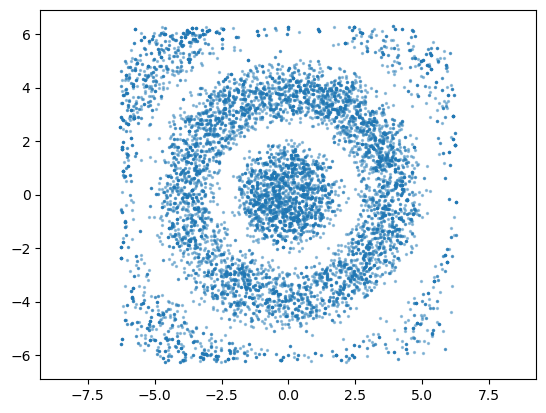

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi, exp, sqrt, sin
from numpy.random import rand, randn

N = 10000
BOUND = 2 * pi

def f(v):
    x1, x2 = v
    if not (-BOUND < x1 < BOUND and -BOUND < x2 < BOUND):
        return 0.0

    r = sqrt(x1**2 + x2**2)
    return exp(-r / 4) * (sin(2 * r) + 1)

samples = np.zeros((N, 2))
x = np.zeros(2)
f_x = f(x)

for i in range(1, N):
    y = x + randn(2)
    f_y = f(y)

    alpha = 0.0
    if f_x > 0:
        alpha = min(f_y / f_x, 1.0)
    elif f_y > 0:
        alpha = 1.0

    if rand() < alpha:
        x = y
        f_x = f_y

    samples[i, :] = x

plt.scatter(samples[:, 0], samples[:, 1], alpha=0.4, s=2)
plt.axis('equal')
plt.show()